# Fig 6: Soil Gated Gumbel Model — ASV-level functional grouping

GatedModel predictions on soil ASV data: consensus groups, gene table, pH-abundance relationships,
per-soil group ratio vs NO3 consumption rate.

In [2]:
%cd /home/schmittms/project_vitelli_matthew/scifi_public/fig6_soil_gated

import sys, os
sys.path.insert(0, '/home/schmittms/project_vitelli_matthew/scifi_public/')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import torch
import pandas as pd
import glob
from tqdm.autonotebook import tqdm
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import SplineTransformer

from dataset import SoilDatasetFiltered
from utils.models import GatedModel

plt.rcParams['axes.prop_cycle'] = plt.cycler(color=plt.cm.Set1.colors)
plt.rcParams['figure.figsize'] = [3, 2]
plt.rcParams['figure.dpi'] = 200
plt.rcParams['svg.fonttype'] = 'none'

device = torch.device('cpu')


%load_ext autoreload
%autoreload 2
%matplotlib inline
pd.options.display.max_columns = None

/project/vitelli/matthew/torch_venv/lib/python3.12/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


/project/vitelli/matthew/scifi_public/fig6_soil_gated


/scratch/local/jobs/48213344/ipykernel_401836/3186611155.py:12: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


## Load models and build loss_df

In [ ]:
masterroot = './trained_models'

np.sort(os.listdir(masterroot))

In [ ]:
masterroot = './trained_models'


subroots = [
    'gatedgumbel_260411_214739_targets-no3_N-128_L-2_0',
       'gatedgumbel_260411_215054_targets-no3_N-128_L-2_1',
       'gatedgumbel_260411_220006_targets-no3_N-128_L-2_2',
       'gatedgumbel_260411_220434_targets-no3_N-128_L-2_3',
       'gatedgumbel_260411_220434_targets-no3_N-128_L-2_4',
       'gatedgumbel_260411_220650_targets-no3_N-128_L-2_5',
       'gatedgumbel_260411_221025_targets-no3_N-128_L-2_6',
       'gatedgumbel_260411_221026_targets-no3_N-128_L-2_7'
]

loss_df = []
for sr in tqdm(subroots):
    root = os.path.join(masterroot, sr)
    if not os.path.isdir(root):
        continue

    files = sorted(glob.glob(os.path.join(root, '*.pt')))
    if len(files) == 0:
        continue

    beta = float(sr.split('_')[9][5:]) if 'beta-' in sr else np.nan

    for path in files:
        file = os.path.basename(path)
        parts = file.split('_')
        if len(parts) < 3:
            continue

        try:
            tax = parts[0].split('-')[-1]
            npcs = int(parts[1].split('-')[-1])
            ensidx = int(parts[2].split('-')[-1].split('.')[0])
        except Exception:
            continue

        x = torch.load(path, map_location=device)

        model_kwargs = x.get('model_kwargs', {})
        kwargs_1 = model_kwargs.get(1, {})
        opt_h = kwargs_1.get('optimizer_hparams', {})
        net_h = kwargs_1.get('network_hparams', {})

        lr = opt_h.get('LR', np.nan)
        gate_lr = opt_h.get('gate_LR', np.nan)
        dropout = net_h.get('dropout', np.nan)


        pred_train = np.asarray(x.get('pred_train', []))
        targ_train = np.asarray(x.get('target_train', []))
        pred_test = np.asarray(x.get('pred_test', []))
        targ_test = np.asarray(x.get('target_test', []))

        r2_train = x.get('r2_train', np.nan)
        r2_test = x.get('r2_test', np.nan)

        tau_hparams = x.get('tau_hparams', {})
        tauparams = {'tau_' + k: v for k, v in tau_hparams.items()}

        loss_df.append({
            'tax': tax,
            'npcs': npcs,
            'CHL': x.get('train_dataset_kwargs', {}).get('CHL', np.nan),
            'outputs': x.get('train_dataset_kwargs', {}).get('pred_vars', ''),
            'n_steps_used': len(x.get('test_losses', [])),
            'ensidx': ensidx,
            'tau': x.get('curr_tau', np.nan),
            'train_loss': x.get('train_losses', []),
            'test_loss': x.get('test_losses', []),
            'train_preds': pred_train.squeeze() if pred_train.size else pred_train,
            'train_targets': targ_train.squeeze() if targ_train.size else targ_train,
            'test_preds': pred_test.squeeze() if pred_test.size else pred_test,
            'test_targets': targ_test.squeeze() if targ_test.size else targ_test,
            'r2_test': r2_test,
            'r2_train': r2_train,
            'proj': np.asarray(x.get('proj', np.nan)),
            'proj_det': np.asarray(x.get('proj_det', np.nan)),
            'gate': np.asarray(x.get('gate', np.nan)),
            'logits': np.asarray(x.get('proj_logits', np.nan)),
            'lr': lr,
            'gate_lr': gate_lr,
            'beta': x.get('beta', beta),
            'dropout': dropout,
            'modelpath': path,
            **tauparams,
        })

loss_df = pd.DataFrame(loss_df)
if len(loss_df) == 0:
    raise RuntimeError('No matching checkpoints found under ./trained_models for the listed subroots.')

x_ref = torch.load(loss_df.iloc[0]['modelpath'], map_location=device)
x_ref['train_dataset_kwargs']['device'] = device
x_ref['train_dataset_kwargs']['CHL'] = 'neg'
dataset_train_neg = SoilDatasetFiltered(**x_ref['train_dataset_kwargs'])
x_ref['train_dataset_kwargs']['CHL'] = 'both'
dataset_train_both = SoilDatasetFiltered(**x_ref['train_dataset_kwargs'])

print('loss_df shape:', loss_df.shape)

  0%|          | 0/8 [00:00<?, ?it/s]

loss_df shape: (480, 27)


In [5]:
loss_df

,tax,npcs,CHL,outputs,n_steps_used,ensidx,tau,train_loss,test_loss,train_preds,train_targets,test_preds,test_targets,r2_test,r2_train,proj,proj_det,gate,logits,lr,gate_lr,beta,dropout,modelpath,tau_init,tau_relax_rate,tau_min
0,ASV,1,both,no3,200,0,0.270643,"[0.19788975, 0.15966178, 0.16513376, 0.1379737...","[0.19533174, 0.20378736, 0.19241339, 0.1592650...","[[1.9819148, 2.024513, 1.9456697, 1.84176, 1.8...","[[2.0802088, 1.9055966, 2.010306, 1.7784172, 1...","[[2.0653515, 2.0689936, 1.9543895, 1.7782013, ...","[[2.108981, 2.0018756, 1.7624902, 1.3977746, 1...",0.705354,0.769289,"[[1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1....","[[1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1....","[[1.9369997e-08], [1.0], [1.0], [1.0], [1.0], ...","[[0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0....",0.010,0.001,0.1,0.2,./trained_models/gatedgumbel_260411_214739_tar...,2.0,0.9999,0.1
1,ASV,1,both,no3,200,1,0.270643,"[0.21428885, 0.18132277, 0.1636818, 0.14637946...","[0.2640096, 0.2243846, 0.19549647, 0.186829, 0...","[[2.0060089, 2.0140464, 1.9904364, 1.9659655, ...","[[2.1186044, 1.9749655, 2.042593, 1.9724201, 2...","[[2.0035777, 1.978571, 1.9666982, 1.8662783, 1...","[[2.2111294, 2.0724359, 2.077714, 1.8075039, 1...",0.664132,0.784781,"[[1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1....","[[1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1....","[[1.9448366e-08], [1.0], [1.0], [1.0], [1.0], ...","[[0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0....",0.010,0.001,0.1,0.2,./trained_models/gatedgumbel_260411_214739_tar...,2.0,0.9999,0.1
2,ASV,1,both,no3,200,10,0.270643,"[0.20846945, 0.17314498, 0.1591172, 0.14334679...","[0.23358318, 0.17589289, 0.1773112, 0.16799842...","[[2.0640616, 2.0784185, 2.076903, 2.018273, 1....","[[2.0798728, 1.9910332, 2.0376265, 2.0645452, ...","[[2.0143034, 1.9901152, 1.9862651, 1.8619646, ...","[[2.1408439, 1.999564, 1.9908022, 1.8159776, 1...",0.703723,0.780067,"[[1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1....","[[1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1....","[[2.002833e-08], [1.0], [1.0], [1.0], [1.0], [...","[[0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0....",0.010,0.001,0.1,0.2,./trained_models/gatedgumbel_260411_214739_tar...,2.0,0.9999,0.1
3,ASV,1,both,no3,200,11,0.270643,"[0.20757684, 0.17663985, 0.15827788, 0.1534011...","[0.24263413, 0.19508407, 0.18184246, 0.1651329...","[[2.0403974, 1.979935, 1.915092, 1.7096735, 1....","[[2.0060172, 1.9504942, 1.8226976, 1.6311551, ...","[[1.9317889, 1.9523525, 1.9090742, 1.8142885, ...","[[1.9910762, 1.9746325, 2.015737, 1.8886807, 1...",0.768329,0.753870,"[[1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1....","[[1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1....","[[2.0508802e-08], [1.0], [1.0], [1.0], [1.0], ...","[[0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0....",0.010,0.001,0.1,0.2,./trained_models/gatedgumbel_260411_214739_tar...,2.0,0.9999,0.1
4,ASV,1,both,no3,200,2,0.270643,"[0.21993572, 0.1900135, 0.17111936, 0.17434743...","[0.2247735, 0.15649326, 0.14813249, 0.1531922,...","[[1.983862, 2.0084019, 1.9665016, 1.8753335, 1...","[[1.9795499, 1.8568467, 1.9298966, 1.8301139, ...","[[1.9876038, 1.9863613, 1.9589658, 1.843957, 1...","[[1.7798848, 1.9224265, 1.7108111, 1.8225662, ...",0.702388,0.743655,"[[1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1....","[[1.0], [1.0], [1.0], [1.0], [1.0], [1.0], [1....","[[1.9507587e-08], [1.0], [1.0], [1.0], [1.0], ...","[[0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0....",0.010,0.001,0.1,0.2,./trained_models/gatedgumbel_260411_214739_tar...,2.0,0.9999,0.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
475,ASV,6,neg,no3,200,5,0.270643,"[0.20844562, 0.15272664, 0.13102652, 0.1137307...","[0.21120305, 0.14424703, 0.1167073, 0.11151936...","[[2.1169891, 2.072237, 1.9890192, 1.8220145, 1...","[[1.8780901, 2.0085185, 2.07451, 1.820825, 1.7...","[[2.0051394, 2.0048742, 1.9322816, 1.7843949, ...","[[2.0312629, 1.8909905, 1.882219, 1.7095003, 1...",0.856619,0.972287,"[[3.353748e-06, 2.411

In [6]:
# print hyperparams
hyperparams = loss_df[['lr', 'dropout', 'tau_init', 'CHL', 'beta', 'gate_lr', 'tau_relax_rate', 'tau_min']].drop_duplicates()
print(f'Found {len(hyperparams)} unique hyperparameter combinations')
hyperparams

Found 8 unique hyperparameter combinations


,lr,dropout,tau_init,CHL,beta,gate_lr,tau_relax_rate,tau_min
0,0.010,0.2,2.0,both,0.1,0.001,0.9999,0.1
60,0.010,0.2,2.0,neg,0.1,0.001,0.9999,0.1
120,0.001,0.2,2.0,both,0.1,0.001,0.9999,0.1
180,0.001,0.2,2.0,neg,0.1,0.001,0.9999,0.1
240,0.010,0.1,2.0,both,0.1,0.001,0.9999,0.1
300,0.010,0.1,2.0,neg,0.1,0.001,0.9999,0.1
360,0.001,0.1,2.0,both,0.1,0.001,0.9999,0.1
420,0.001,0.1,2.0,neg,0.1,0.001,0.9999,0.1


## Load metadata and gene annotation table

In [7]:
abund_meta = pd.read_excel(
    '/project/vitelli/matthew/soil_microbiome_model_reduction/data_raw/ASV_table_and_metadata/230329_df_refseq_taxtable_toSiqi.xlsx',
    dtype='str')
abund_meta.set_index('ASV', inplace=True)

kegg_identifiers = {
    'K00362': 'nirB', 'K00363': 'nirD', 'K00368': 'nirK',
    'K00370': 'narGnarZnxrA', 'K00371': 'narHnarYnxrB', 'K00374': 'narInarV',
    'K00376': 'nosZ', 'K02305': 'norC', 'K02567': 'napA', 'K02568': 'napB',
    'K03385': 'nrfA', 'K04561': 'norB', 'K15864': 'nirS', 'K15876': 'nrfH'
}

asv_to_gene_table = pd.read_csv(
    '/project/vitelli/matthew/soil_microbiome_model_reduction/data_raw/df_KO_predicted_dada2_refseq.csv')
asv_to_gene_table = asv_to_gene_table.rename(columns=kegg_identifiers)
asv_to_gene_table.head()

,ASV,nirB,nirD,nirK,narGnarZnxrA,narHnarYnxrB,narInarV,nosZ,norC,napA,napB,nrfA,norB,nirS,nrfH,Sequence,Kingdom,Phylum,Class,Order,Family,Genus,Species
0,ASV1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,TGAGGAATATTGGTCAATGGCCGAGAGGCTGAACCAGCCAAGTCGC...,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,Tannerellaceae,Parabacteroides,merdae
1,ASV10,0,1,0,0,0,0,0,0,0,0,0,0,0,0,TGGGGAATTTTGCGCAATGGGGGAAACCCTGACGCAGCAACGCCGC...,Bacteria,Acidobacteriota,Acidobacteriae,Acidobacteriales,NaN,NaN,NaN
2,ASV100,0,1,0,0,0,0,0,0,0,0,0,0,0,0,TGGGGAATTTTGCGCAATGGGGGAAACCCTGACGCAGCAACGCCGC...,Bacteria,Acidobacteriota,Acidobacteriae,Acidobacteriales,NaN,NaN,NaN
3,ASV1000,0,1,0,0,0,0,0,0,0,0,0,1,0,0,TCGGGAATTTTGGGCAATGGGCGAAAGCCTGACCCAGCAACGCCGC...,Bacteria,Acidobacteriota,Blastocatellia,Blastocatellales,Blastocatellaceae,NaN,NaN
4,ASV10000,2,1,0,0,0,0,0,0,0,0,1,0,0,1,TAGGGAATCTTCCGCAATGGACGAAAGTCTGACGGAGCAACGCCGC...,Bacteria,Firmicutes,Bacilli,Bacillales,Bacillaceae,Bacillus,selenatarsenatis


## Compute consensus group assignments

In [52]:
DO = 0.1
lr = 1e-3
gate_lr = 1e-3
beta = 1e-1
tax = 'ASV'
npc = 2
chl = 'both'
outputs = 'no3'
n_ensemble_keep = 3
THRESHOLD = 0.7
dataset = dataset_train_neg if chl=='neg' else dataset_train_both


abund_final = dataset.inputs[tax].detach().cpu().numpy()
abund_init = dataset.comp_t0_asv

no3_pc1 = np.linalg.svd(dataset.no3, full_matrices=False)[0][:,0]

mask = (loss_df.dropout==DO)&(loss_df.npcs==npc)&(loss_df.gate_lr==gate_lr)\
    &(loss_df.beta==beta)&(loss_df.tax==tax)&(loss_df.CHL==chl)\
    &(loss_df.outputs==outputs)&(loss_df.lr==lr)

print(len(loss_df.loc[mask]))

test_r2 = loss_df.loc[mask, 'r2_test'].values

print("R2s\n", np.sort(test_r2)[::-1])

ensembled_sorted = loss_df.loc[mask, 'ensidx'].values[np.argsort(test_r2)[::-1]]
ensembled_sorted = ensembled_sorted[:n_ensemble_keep] # keep only highest R2

CHLNEG_MASK = dataset.df.Chloramphenicol==0

single_strain_avg_group_assignment_chlneg = np.zeros((len(ensembled_sorted), abund_final.shape[1], npc))
single_strain_avg_group_assignment_chlpos = np.zeros((len(ensembled_sorted), abund_final.shape[1], npc))
group_abundances_final = np.zeros((n_ensemble_keep, abund_final.shape[0], npc))
group_abundances_init = np.zeros((n_ensemble_keep, abund_final.shape[0], npc))
all_projs = np.zeros((len(ensembled_sorted), abund_final.shape[1], npc))
for e, ens_idx in enumerate(ensembled_sorted):
    proj = loss_df.loc[mask&(loss_df.ensidx==ens_idx), 'proj_det'].values[0]
    gate = loss_df.loc[mask&(loss_df.ensidx==ens_idx), 'gate'].values[0]

    # Make deterministic. Established elsewhere that this does not change results
    proj[np.arange(len(proj)), np.argmax(proj, axis=1)] = 1
    proj[proj<1] = 0

    all_projs[e] = proj * gate 

    gp_abd_final, gp_abd_init = [], []
    corrs = []
    for i in range(npc):
        intragp_abd_final = abund_final * proj[None,:,i] * gate.T # Get "masked" abundance before projecting, shape = [N samp, N spec]
        intragp_abd_init = abund_init * (proj>0)[None,:,i] * gate.T 
        gp_abd_final.append(np.sum(intragp_abd_final, axis=1)) # Sum over species to get group abundance, shape = [N samp,]
        gp_abd_init.append(np.sum(intragp_abd_init, axis=1))

        single_strain_avg_group_assignment_chlneg[e,:,i] = np.mean(intragp_abd_final[CHLNEG_MASK], axis=0) # Average over samples to get 
        single_strain_avg_group_assignment_chlpos[e,:,i] = np.mean(intragp_abd_final[~CHLNEG_MASK], axis=0) #    single strain contribution to group

        corrs.append(np.mean(np.mean(intragp_abd_final, axis=1)))

    gp_abd_final = np.asarray(gp_abd_final).T
    gp_abd_init = np.asarray(gp_abd_init).T

    # Sort to get consistent group ordering
    group_sort = np.argsort(corrs)[::-1]
    gp_abd_final = gp_abd_final[:, group_sort]
    gp_abd_init = gp_abd_init[:, group_sort]
    all_projs[e] = all_projs[e][:, group_sort]
    single_strain_avg_group_assignment_chlneg[e] = single_strain_avg_group_assignment_chlneg[e][:, group_sort]
    single_strain_avg_group_assignment_chlpos[e] = single_strain_avg_group_assignment_chlpos[e][:, group_sort]

    group_abundances_final[e] = gp_abd_final
    group_abundances_init[e] = gp_abd_init


# Get indices of group 1 and group 2 species, sorted in descending order of average abundance
master_idx = np.mean(np.max(all_projs, axis=2), axis=0)>THRESHOLD
master_idx_int = np.where(master_idx)[0]

print("Species kept:\t", len(master_idx_int))

mean_assignments = np.mean(single_strain_avg_group_assignment_chlneg[:,master_idx_int,:], axis=0)
std_assignments = np.std(single_strain_avg_group_assignment_chlneg[:,master_idx_int,:], axis=0)
sort_asv_by_abd_and_group = np.argsort(mean_assignments[:,0] - mean_assignments[:,-1])[::-1]

consensus_projs = all_projs[:, master_idx_int, :][:,sort_asv_by_abd_and_group, :]

mean_assignments = mean_assignments[sort_asv_by_abd_and_group]
std_assignments = std_assignments[sort_asv_by_abd_and_group]
master_idx_int = master_idx_int[sort_asv_by_abd_and_group]

group_1_idx_within_subset = np.where(np.sum(all_projs[:,master_idx_int,:], axis=0)[:,0] > np.sum(all_projs[:,master_idx_int,:], axis=0)[:,1])[0]
group_2_idx_within_subset = np.where(np.sum(all_projs[:,master_idx_int,:], axis=0)[:,1] > np.sum(all_projs[:,master_idx_int,:], axis=0)[:,0])[0]
group_2_idx_within_subset = group_2_idx_within_subset[::-1] # so descending order of abundance

group_1_idx = master_idx_int[group_1_idx_within_subset]
group_2_idx = master_idx_int[group_2_idx_within_subset]

group_1_asvs = dataset.taxa_ordered_names[tax+'_filt'][dataset.sort_idx[tax]][group_1_idx]
group_2_asvs = dataset.taxa_ordered_names[tax+'_filt'][dataset.sort_idx[tax]][group_2_idx]

consensus_group_1_abd_final = np.sum(abund_final[:, group_1_idx], axis=1)
consensus_group_2_abd_final = np.sum(abund_final[:, group_2_idx], axis=1)
consensus_group_1_abd_init = np.sum(abund_init[:, group_1_idx], axis=1)
consensus_group_2_abd_init = np.sum(abund_init[:, group_2_idx], axis=1)



# Get full names
group_1_rows = abund_meta.loc[[str(l) for l in group_1_asvs]].astype(str)
group_1_names = group_1_rows[['Phylum', 'Family', 'Genus', 'Species']].agg(';'.join, axis=1).values # get full name from Phylum, Family, Genus, Species

group_2_rows = abund_meta.loc[[str(l) for l in group_2_asvs]].astype(str)
group_2_names = group_2_rows[['Phylum', 'Family', 'Genus', 'Species']].agg(';'.join, axis=1).values # get full name from Phylum, Family, Genus, Species


12
R2s
 [0.90116076 0.87914094 0.8779218  0.86295874 0.85405655 0.85250407
 0.83569661 0.81916863 0.81732397 0.81248868 0.80523722 0.78945944]
Species kept:	 68


(array([5.1761e+04, 1.2000e+01, 1.8000e+01, 1.7000e+01, 1.2000e+01,
        1.6000e+01, 1.5000e+01, 1.5000e+01, 1.3000e+01, 1.8000e+01,
        2.2000e+01, 1.2000e+01, 1.9000e+01, 1.3000e+01, 1.4000e+01,
        2.1000e+01, 2.0000e+01, 1.0000e+01, 8.0000e+00, 7.0000e+00,
        7.0000e+00, 6.0000e+00, 1.3000e+01, 1.1000e+01, 1.0000e+01,
        8.0000e+00, 5.0000e+00, 3.0000e+00, 5.0000e+00, 6.0000e+00,
        7.0000e+00, 5.0000e+00, 4.0000e+00, 6.0000e+00, 2.0000e+00,
        4.0000e+00, 4.0000e+00, 4.0000e+00, 2.0000e+00, 3.0000e+00,
        3.0000e+00, 2.0000e+00, 0.0000e+00, 1.0000e+00, 4.0000e+00,
        0.0000e+00, 3.0000e+00, 3.0000e+00, 1.0000e+00, 5.6500e+02]),
 array([6.13247186e-09, 2.00000051e-02, 4.00000066e-02, 6.00000061e-02,
        8.00000057e-02, 1.00000009e-01, 1.20000005e-01, 1.40000001e-01,
        1.60000011e-01, 1.80000007e-01, 2.00000003e-01, 2.19999999e-01,
        2.40000010e-01, 2.59999990e-01, 2.80000001e-01, 3.00000012e-01,
        3.19999993e-01, 3.4000

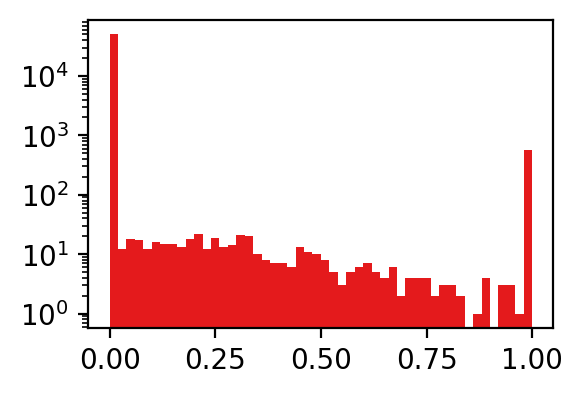

In [40]:
# plot hist of gate values for all species
gates = loss_df.loc[mask, 'gate'].values
gates = np.concatenate(gates, axis=0)
plt.hist(gates.flatten(), bins=50, log=True)

## Consistent projections across ensemble

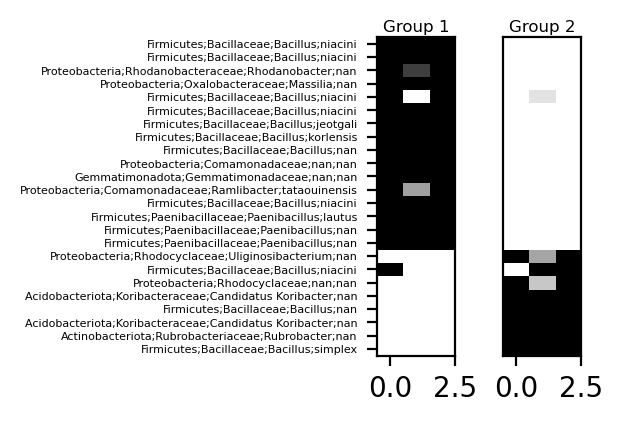

In [41]:
fig, ax = plt.subplots(1, npc, figsize=(3, 2), constrained_layout=True)

for r in range(npc):
    ax[r].imshow(consensus_projs[:, :, r].T, aspect='auto', cmap='binary', vmin=0, vmax=1)
    ax[r].set_title(f'Group {r+1}', fontsize=6, pad=2)

ax[0].set_yticks(np.arange(len(master_idx_int)))
ax[0].set_yticklabels(list(group_1_names) + list(group_2_names[::-1]), fontsize=4)
ax[1].set_yticks([])

if input('save? ').strip().lower() == 'save':
    savepath = f'./figures/SI_consistent_species_threshold_{THRESHOLD}_n_kept_{n_ensemble_keep}.svg'
    fig.savefig(savepath, bbox_inches='tight')

## Average ASV assignments bar chart

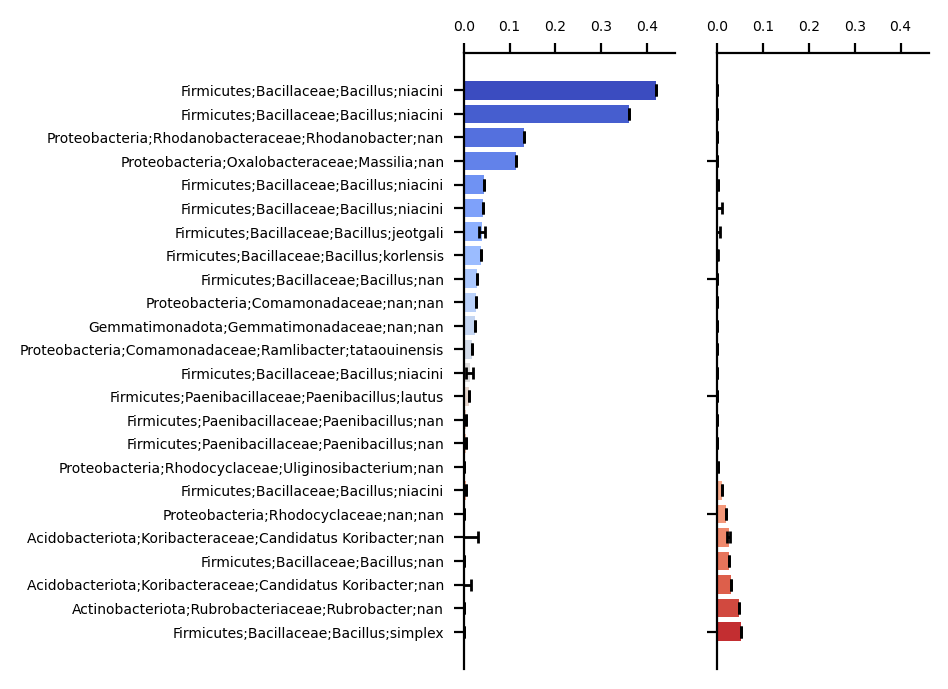

In [42]:
fig, ax = plt.subplots(1, 2, figsize=(3, 4))

n_species = len(group_1_idx) + len(group_2_idx)

ax[0].barh(np.arange(n_species), mean_assignments[::-1, 0],
           xerr=std_assignments[:, 0],
           color=plt.get_cmap('coolwarm')(np.arange(n_species)[::-1] / n_species),
           lw=0, error_kw={'lw': 1, 'capsize': 2, 'ecolor': 'k'})
ax[1].barh(np.arange(n_species), mean_assignments[::-1, 1],
           xerr=std_assignments[:, 1],
           color=plt.get_cmap('coolwarm')(np.arange(n_species)[::-1] / n_species),
           lw=0, error_kw={'lw': 1, 'capsize': 2, 'ecolor': 'k'})

ax[0].set_yticks(np.arange(n_species))
ax[0].set_yticklabels(np.concatenate([group_2_names, group_1_names[::-1]]), fontsize=5)
ax[1].set_yticklabels([])

xlim = max(np.max(mean_assignments[:, 0] + std_assignments[:, 0]),
           np.max(mean_assignments[:, 1] + std_assignments[:, 1])) * 1.1
for a in ax:
    a.set_xlim(0, xlim)
    a.tick_params(axis='x', labelsize=5)
    a.xaxis.tick_top()
    a.xaxis.set_label_position('top')
    a.spines['bottom'].set_visible(False)
    a.spines['right'].set_visible(False)
    a.spines['top'].set_visible(True)

if input('save? ').strip().lower() == 'save':
    fig.savefig(f'./figures/SI_avg_spec_assignments_{outputs}_threshold_{THRESHOLD}_n_kept_{n_ensemble_keep}.svg',
               bbox_inches='tight')

## Group abundance vs pH (main figure)

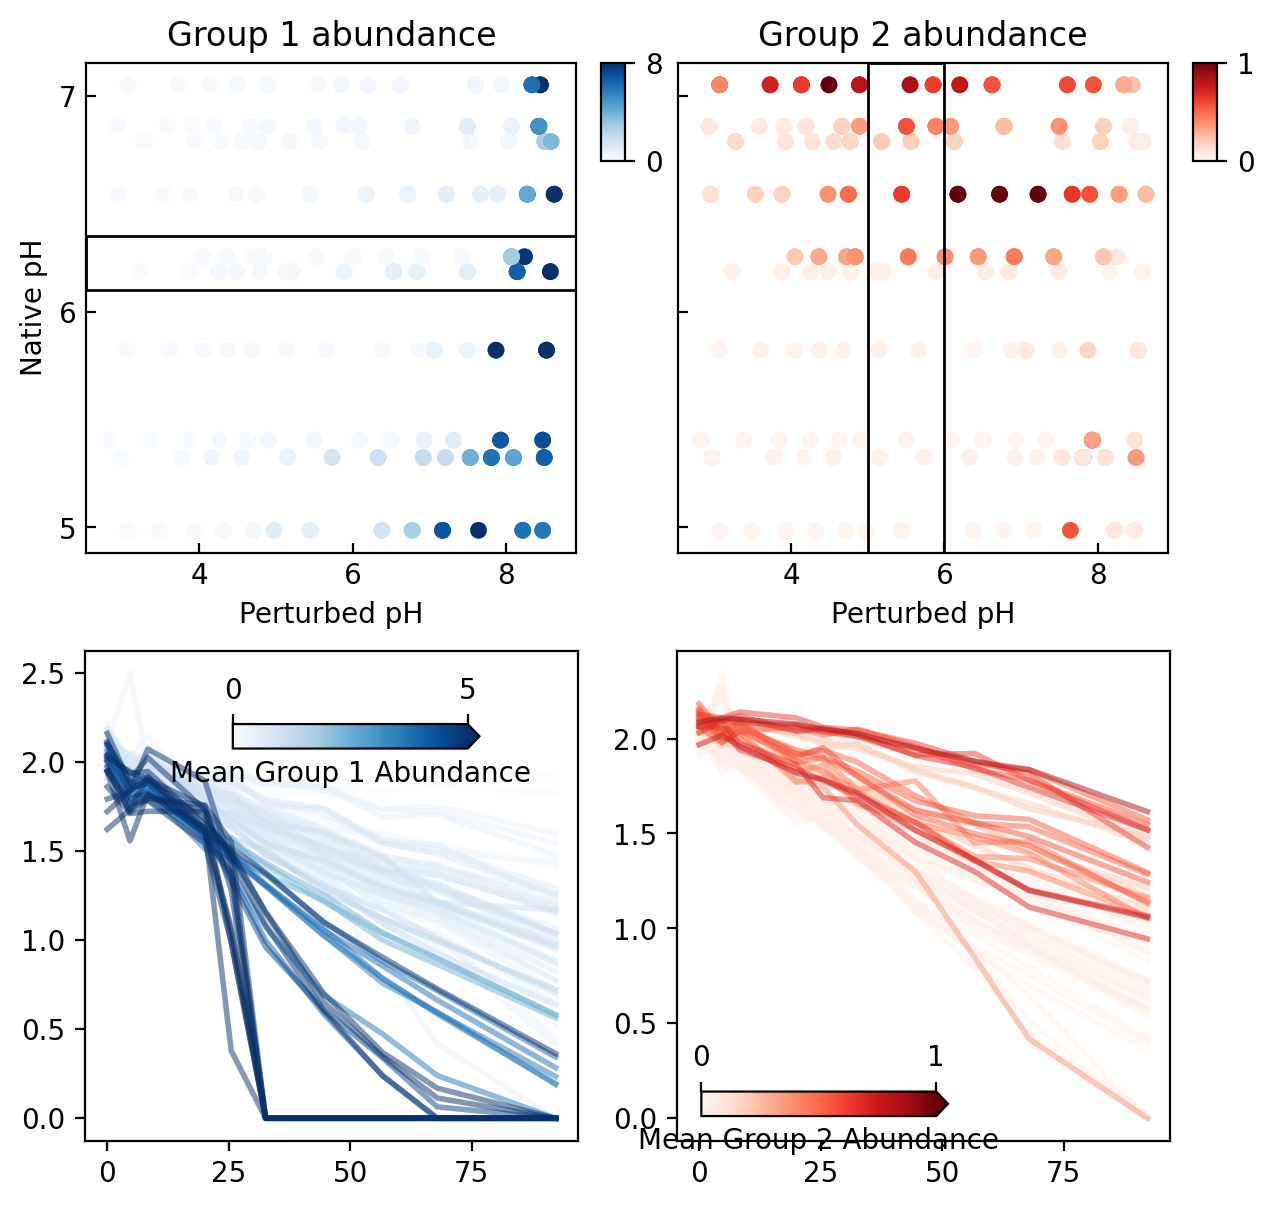

In [43]:
pH_nat = dataset.soil_ph.detach().cpu().numpy()
pH = dataset.ph.detach().cpu().numpy()

abund_1 = consensus_group_1_abd_final[CHLNEG_MASK]
abund_2 = consensus_group_2_abd_final[CHLNEG_MASK]

fig, ax = plt.subplots(2, 2, figsize=(7, 7), dpi=200)

scat_0 = ax[0][0].scatter(pH[CHLNEG_MASK], pH_nat[CHLNEG_MASK], c=abund_1,
                          cmap='Blues', alpha=1, vmax=8, vmin=0, lw=0)
scat_1 = ax[0][1].scatter(pH[CHLNEG_MASK], pH_nat[CHLNEG_MASK], c=abund_2,
                          cmap='Reds', alpha=1, vmax=1, vmin=0, lw=0)

cax_0 = ax[0][0].inset_axes([1.05, 0.8, 0.05, 0.2])
cax_1 = ax[0][1].inset_axes([1.05, 0.8, 0.05, 0.2])
fig.colorbar(scat_0, cax=cax_0, ticks=[0, 8])
fig.colorbar(scat_1, cax=cax_1, ticks=[0, 1])

ax[0][1].set_yticklabels([])
ax[0][0].set_ylabel('Native pH')
for a in ax[0]:
    a.set_xlabel('Perturbed pH')
    a.set_box_aspect(1)
    a.tick_params(direction='in')
    a.set_yticks([5, 6, 7])
ax[0][0].set_title('Group 1 abundance')
ax[0][1].set_title('Group 2 abundance')

# Box overlays
rect = plt.Rectangle((ax[0][0].get_xlim()[0], 6.1),
                      np.diff(ax[0][0].get_xlim())[0], 0.25,
                      linewidth=1, edgecolor='k', facecolor='none')
ax[0][0].add_patch(rect)
rect = plt.Rectangle((5., ax[0][1].get_ylim()[0]),
                      1, np.diff(ax[0][1].get_ylim())[0],
                      linewidth=1, edgecolor='k', facecolor='none')
ax[0][1].add_patch(rect)

box_0 = ((2.52, 2.52 + 6.39), (6.1, 6.1 + 0.25))
box_1 = ((5, 6), (4.88, 4.88 + 2.27))

no3 = dataset.no3.detach().cpu().numpy()
t = dataset.df.Time.values[0]

box_0_mask = ((pH[CHLNEG_MASK] >= box_0[0][0]) & (pH[CHLNEG_MASK] <= box_0[0][1]) &
              (pH_nat[CHLNEG_MASK] >= box_0[1][0]) & (pH_nat[CHLNEG_MASK] <= box_0[1][1]))
box_1_mask = ((pH[CHLNEG_MASK] >= box_1[0][0]) & (pH[CHLNEG_MASK] <= box_1[0][1]) &
              (pH_nat[CHLNEG_MASK] >= box_1[1][0]) & (pH_nat[CHLNEG_MASK] <= box_1[1][1]))

for box0_sample in np.where(box_0_mask)[0]:
    ax[1][0].plot(t, no3[CHLNEG_MASK][box0_sample],
                  color=plt.get_cmap('Blues')(abund_1[box0_sample]),
                  alpha=0.5, lw=2, zorder=abund_1[box0_sample])

cax0 = ax[1][0].inset_axes([0.3, 0.8, 0.5, 0.05])
sm0 = plt.cm.ScalarMappable(cmap='Blues', norm=plt.Normalize(vmin=0, vmax=5))
cb0 = fig.colorbar(sm0, cax=cax0, extend='max', ticks=[0, 5], orientation='horizontal')
cb0.set_label('Mean Group 1 Abundance')
cb0.ax.xaxis.set_ticks_position('top')

for box1_sample in np.where(box_1_mask)[0]:
    ax[1][1].plot(t, no3[CHLNEG_MASK][box1_sample],
                  color=plt.get_cmap('Reds')(abund_2[box1_sample]),
                  alpha=0.5, lw=2, zorder=abund_2[box1_sample])

cax1 = ax[1][1].inset_axes([0.05, 0.05, 0.5, 0.05])
sm1 = plt.cm.ScalarMappable(cmap='Reds', norm=plt.Normalize(vmin=0, vmax=1))
cb1 = fig.colorbar(sm1, cax=cax1, extend='max', ticks=[0, 1], orientation='horizontal')
cb1.set_label('Mean Group 2 Abundance')
cb1.ax.xaxis.set_ticks_position('top')

if input('save? ').strip().lower() == 'save':
    savepath = f'./figures/group_abund_vs_pH_{outputs}_npc-{npc}_DO-{DO}_LR-{lr}_gateLR-{gate_lr}_beta-{beta}_{tax}.svg'
    fig.savefig(savepath, bbox_inches='tight')

In [53]:
for p in loss_df.loc[mask, 'modelpath']:
    print(p)

./trained_models/gatedgumbel_260411_221025_targets-no3_N-128_L-2_6/tax-ASV_Npcs-2_model-0.pt
./trained_models/gatedgumbel_260411_221025_targets-no3_N-128_L-2_6/tax-ASV_Npcs-2_model-1.pt
./trained_models/gatedgumbel_260411_221025_targets-no3_N-128_L-2_6/tax-ASV_Npcs-2_model-10.pt
./trained_models/gatedgumbel_260411_221025_targets-no3_N-128_L-2_6/tax-ASV_Npcs-2_model-11.pt
./trained_models/gatedgumbel_260411_221025_targets-no3_N-128_L-2_6/tax-ASV_Npcs-2_model-2.pt
./trained_models/gatedgumbel_260411_221025_targets-no3_N-128_L-2_6/tax-ASV_Npcs-2_model-3.pt
./trained_models/gatedgumbel_260411_221025_targets-no3_N-128_L-2_6/tax-ASV_Npcs-2_model-4.pt
./trained_models/gatedgumbel_260411_221025_targets-no3_N-128_L-2_6/tax-ASV_Npcs-2_model-5.pt
./trained_models/gatedgumbel_260411_221025_targets-no3_N-128_L-2_6/tax-ASV_Npcs-2_model-6.pt
./trained_models/gatedgumbel_260411_221025_targets-no3_N-128_L-2_6/tax-ASV_Npcs-2_model-7.pt
./trained_models/gatedgumbel_260411_221025_targets-no3_N-128_L-2_6/t

## Group abundance vs native pH with spline fit

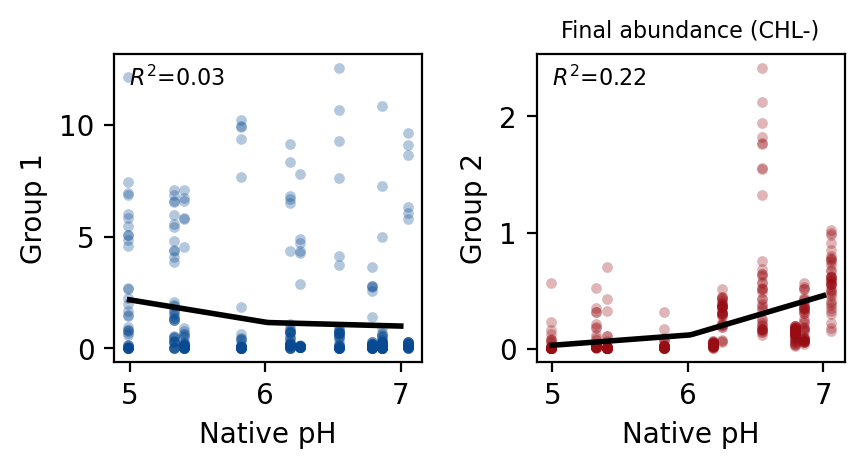

In [44]:
fig, ax = plt.subplots(1, 2, figsize=(5, 2), dpi=200)

group_def = 'consensus'
if group_def == 'consensus':
    abund_1_f = consensus_group_1_abd_final
    abund_2_f = consensus_group_2_abd_final
elif group_def == 'ensemble_mean':
    abund_1_f = np.mean(group_abundances_final[:, :, 0], axis=0)
    abund_2_f = np.mean(group_abundances_final[:, :, 1], axis=0)

alpha = 0.3
ax[0].scatter(pH_nat[CHLNEG_MASK], abund_1_f[CHLNEG_MASK],
              color=plt.get_cmap('Blues')(0.9), s=15, lw=0, alpha=alpha)
ax[1].scatter(pH_nat[CHLNEG_MASK], abund_2_f[CHLNEG_MASK],
              color=plt.get_cmap('Reds')(0.9), s=15, lw=0, alpha=alpha)

ax[0].set_xlabel('Native pH')
ax[1].set_xlabel('Native pH')
ax[0].set_ylabel('Group 1')
ax[1].set_ylabel('Group 2')
ax[1].set_title('Final abundance (CHL-)', fontsize=8)

x = pH_nat[CHLNEG_MASK]
for i, y in enumerate([abund_1_f, abund_2_f]):
    y = y[CHLNEG_MASK]
    x_reshape = x[:, None]
    spline_transformer = SplineTransformer(degree=1, n_knots=3)
    spline_transformer.fit(x_reshape)
    X_spline = spline_transformer.transform(x_reshape)
    model_lr = LinearRegression()
    model_lr.fit(X_spline, y)
    x_fit = np.linspace(5, 7, 100)
    X_fit_spline = spline_transformer.transform(x_fit[:, None])
    y_fit = model_lr.predict(X_fit_spline)
    ax[i].plot(x_fit, y_fit, color='k', lw=2)
    y_pred = model_lr.predict(X_spline)
    r2 = 1 - np.sum((y - y_pred)**2) / np.sum((y - np.mean(y))**2)
    ax[i].text(0.05, 0.9, f'$R^2$={r2:.2f}', transform=ax[i].transAxes, fontsize=8)

for a in ax.flat:
    a.set_box_aspect(1)
    a.set_xticks(np.arange(5, 8))

if input('save? ').strip().lower() == 'save':
    fig.savefig(f'./figures/group_abd_vs_natph_{outputs}_npc-{npc}_DO-{DO}_LR-{lr}_gateLR-{gate_lr}_beta-{beta}_{tax}.svg',
               bbox_inches='tight')

## Gene table + group membership + ASV abundance

(24, 6)


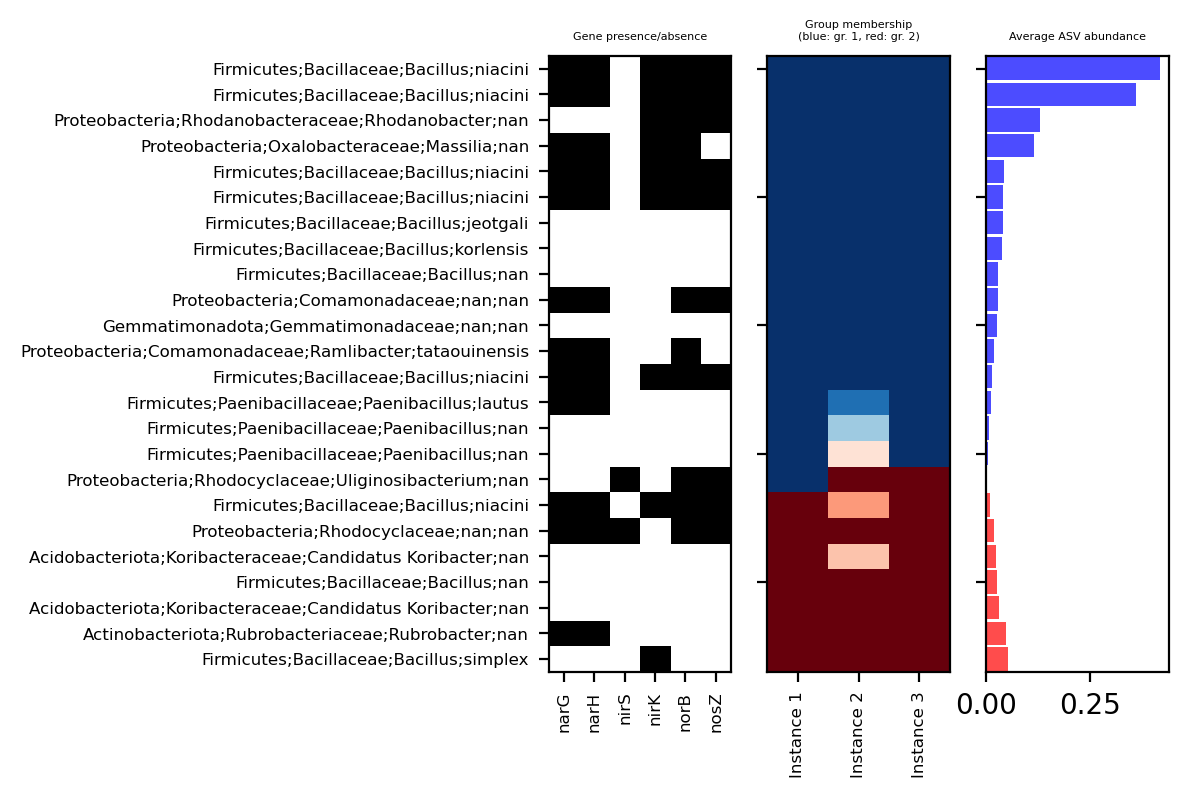

In [45]:
cols_order = ['narGnarZnxrA', 'narHnarYnxrB', 'nirS', 'nirK', 'norB', 'nosZ']

ASV_list = list(group_1_asvs) + list(group_2_asvs[::-1])
gene_copy_numbers = asv_to_gene_table[asv_to_gene_table.ASV.isin(ASV_list)].copy()

# Manual gene corrections from isolation experiments
niacini_genes = {'narGnarZnxrA': 1, 'narHnarYnxrB': 1, 'napA': 0,
                 'nrfA': 1, 'nrfH': 1, 'nirB': 0,
                 'nirK': 1, 'nirS': 0, 'norB': 1, 'nosZ': 1}
fumarioli_genes = niacini_genes.copy()
simplex_genes = {'nirK': 1}

for gene, val in niacini_genes.items():
    gene_copy_numbers.loc[gene_copy_numbers.Species == 'niacini', gene] = val
for gene, val in simplex_genes.items():
    gene_copy_numbers.loc[gene_copy_numbers.Species == 'simplex', gene] = val
for gene, val in fumarioli_genes.items():
    gene_copy_numbers.loc[gene_copy_numbers.Species == 'fumarioli', gene] = val

gene_copy_numbers = gene_copy_numbers.set_index('ASV').loc[ASV_list].drop(
    columns=['Sequence', 'Class', 'Order', 'Kingdom', 'Phylum', 'Family', 'Genus', 'Species'])
gene_copy_numbers = gene_copy_numbers[cols_order]

print(gene_copy_numbers.shape)

fig, ax = plt.subplots(1, 3, figsize=(4, 4), dpi=200)

idx_srt = np.argsort(np.mean(consensus_projs[:, :, 0], axis=0))[::-1]
projs0 = consensus_projs[:, :, 0][:, idx_srt].copy()
projs1 = consensus_projs[:, :, 1][:, idx_srt].copy()
projs0[projs0 == 0] = np.nan
projs1[projs1 == 0] = np.nan

ax[0].imshow(gene_copy_numbers, aspect='auto', cmap='binary', vmin=0, vmax=1)
ax[1].imshow(projs0.T, cmap='Blues', vmin=0, vmax=1, aspect='auto')
ax[1].imshow(projs1.T, cmap='Reds', vmin=0, vmax=1, alpha=1, aspect='auto')

ax[2].barh(np.arange(len(group_1_idx)),
           np.mean(single_strain_avg_group_assignment_chlneg, axis=0)[group_1_idx, 0],
           color='b', alpha=0.7, height=0.9)
ax[2].barh(len(group_1_idx) + np.arange(len(group_2_idx)),
           np.mean(single_strain_avg_group_assignment_chlneg, axis=0)[group_2_idx[::-1], 1],
           color='r', alpha=0.7, height=0.9)
ax[2].set_ylim(-0.5, len(group_1_idx) + len(group_2_idx) - 0.5)
ax[2].invert_yaxis()

ax[1].set_yticklabels([])
ax[2].set_yticklabels([])
ax[0].set_yticks(np.arange(len(gene_copy_numbers)))
ax[0].set_yticklabels(list(group_1_names) + list(group_2_names[::-1]), fontsize=6)
ax[0].set_xticks(np.arange(len(cols_order)))
ax[0].set_xticklabels([c[:4] for c in cols_order], rotation=90, fontsize=6)

ax[0].set_title('Gene presence/absence', fontsize=4)
ax[1].set_title('Group membership\n(blue: gr. 1, red: gr. 2)', fontsize=4)
ax[2].set_title('Average ASV abundance', fontsize=4)
ax[1].set_xticks(np.arange(n_ensemble_keep))
ax[1].set_xticklabels([f'Instance {i+1}' for i in range(n_ensemble_keep)], rotation=90, fontsize=6)

if input('save? ').strip().lower() == 'save':
    fig.savefig(f'./figures/GeneTable_vs_Abund_threshold_{THRESHOLD}_n_ens_keep_{n_ensemble_keep}.svg',
               bbox_inches='tight')

## Per-soil group ratio + NO3 consumption rate vs perturbed pH

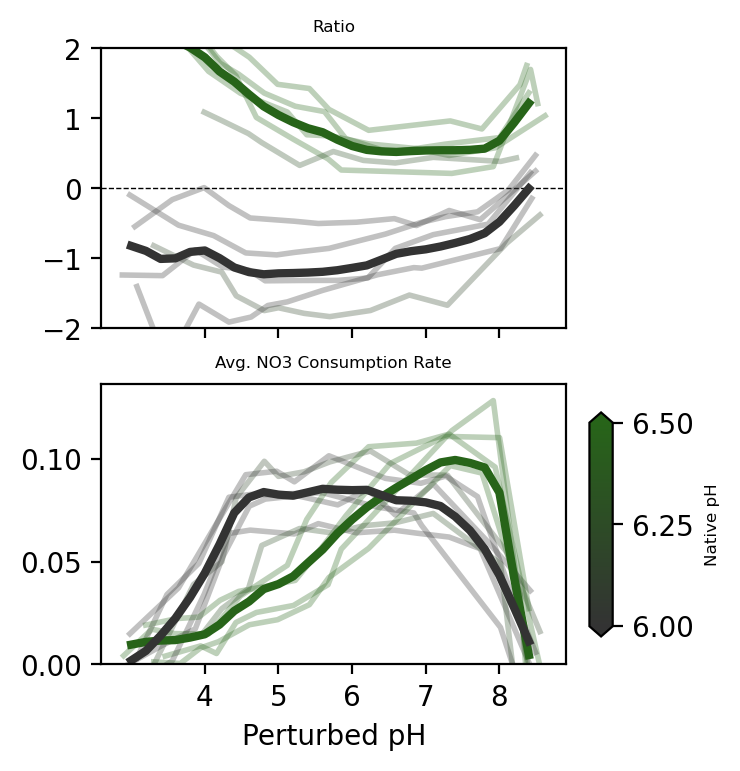

In [46]:
green_anchor = plt.get_cmap('PiYG')(1.0)
gray_anchor = (0.2, 0.2, 0.2, 1.0)
cmap_gg = mcolors.LinearSegmentedColormap.from_list('GrayGreen', [gray_anchor, green_anchor])

fig, ax = plt.subplots(2, 1, figsize=(3, 4), dpi=200)

units_unq = dataset.df.Unit.unique()
soils_unq = dataset.df.Soil.unique()

group_abundances_ensemble_mean_final = np.mean(group_abundances_final, axis=0)
group_abundances_ensemble_mean_init = np.mean(group_abundances_init, axis=0)

no3 = dataset.no3.detach().cpu().numpy()
t = np.asarray(dataset.df.Time.values[0])
no3_slope = -np.mean(np.diff(no3, axis=1), axis=1)

neutral_ratio_interp, acidic_ratio_interp = [], []
neutral_no3_slope_interp, acidic_no3_slope_interp = [], []
pert_ph_interpolated = np.arange(3., 8.5, 0.2)

for soil in soils_unq:
    ph_pert_avgs, ph_nat_avgs = [], []
    no3_slope_avgs_soil = []
    gp1f_avgs, gp2f_avgs = [], []

    for unit in units_unq:
        m = (dataset.df.Unit == unit) & (dataset.df.Soil == soil) & (dataset.df.Chloramphenicol == 1)
        if np.sum(m) == 0:
            continue
        ph_pert_avgs.append(np.mean(dataset.ph[m].detach().cpu().numpy()))
        ph_nat_avgs.append(np.mean(dataset.soil_ph[m].detach().cpu().numpy()))
        no3_slope_avgs_soil.append(np.mean(no3_slope[m]))
        gp1f_avgs.append(np.mean(group_abundances_ensemble_mean_final[m, 0]))
        gp2f_avgs.append(np.mean(group_abundances_ensemble_mean_final[m, 1]))

    sort_idx = np.argsort(ph_pert_avgs)
    ph_pert_avgs = np.array(ph_pert_avgs)[sort_idx]
    no3_slope_avgs_soil = np.array(no3_slope_avgs_soil)[sort_idx]
    gp1f_avgs = np.array(gp1f_avgs)[sort_idx]
    gp2f_avgs = np.array(gp2f_avgs)[sort_idx]
    c = np.mean(ph_nat_avgs)

    ratio = np.log2(gp2f_avgs / gp1f_avgs)
    ax[0].plot(ph_pert_avgs, ratio, color=plt.get_cmap(cmap_gg)((c - 6) / 0.5),
              linestyle='-', alpha=0.3, lw=2)
    ax[1].plot(ph_pert_avgs, no3_slope_avgs_soil, color=plt.get_cmap(cmap_gg)((c - 6) / 0.5),
              linestyle='-', alpha=0.3, lw=2)

    ratio_interp = np.interp(pert_ph_interpolated, ph_pert_avgs, ratio)
    no3_s_interp = np.interp(pert_ph_interpolated, ph_pert_avgs, no3_slope_avgs_soil)

    if c >= 6.25:
        neutral_ratio_interp.append(ratio_interp)
        neutral_no3_slope_interp.append(no3_s_interp)
    else:
        acidic_ratio_interp.append(ratio_interp)
        acidic_no3_slope_interp.append(no3_s_interp)

lw = 3
ax[0].plot(pert_ph_interpolated, np.mean(neutral_ratio_interp, axis=0),
           color=plt.get_cmap(cmap_gg)(1.0), linewidth=lw, label='Neutral Avg.')
ax[0].plot(pert_ph_interpolated, np.mean(acidic_ratio_interp, axis=0),
           color=plt.get_cmap(cmap_gg)(0.0), linewidth=lw, label='Acidic Avg.')
ax[1].plot(pert_ph_interpolated, np.mean(neutral_no3_slope_interp, axis=0),
           color=plt.get_cmap(cmap_gg)(1.0), linewidth=lw, label='Neutral Avg.')
ax[1].plot(pert_ph_interpolated, np.mean(acidic_no3_slope_interp, axis=0),
           color=plt.get_cmap(cmap_gg)(0.0), linewidth=lw, label='Acidic Avg.')

ax[0].set_ylim(-2, 2)
ax[1].set_ylim(0, None)
for a in ax:
    a.set_xticks(np.arange(4, 9, 1))
ax[0].set_xticklabels([])
ax[1].set_xlabel('Perturbed pH')
ax[0].axhline(0, color='k', linestyle='--', linewidth=0.5, zorder=-100)
ax[0].set_title('Ratio', fontsize=6)
ax[1].set_title('Avg. NO3 Consumption Rate', fontsize=6)

cax = ax[-1].inset_axes([1.05, 0.1, 0.05, 0.8])
norm = plt.Normalize(vmin=6, vmax=6.5)
cb = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap_gg), cax=cax, extend='both')
cb.set_label('Native pH', fontsize=6)
cb.set_ticks([6.0, 6.25, 6.5])

if input('save? ').strip().lower() == 'save':
    fig.savefig(f'./figures/fig6_Gp_Ratio_and_NO3_rate_vs_pH_threshold_{THRESHOLD}_n_ens_keep_{n_ensemble_keep}_no_avg.svg',
               bbox_inches='tight')